# Color Spaces

## Objectives:

1. Observe the individual channels of a color image
2. Manipulate Color Spaces
3. Introduce HSV Color Spaces

> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
# Our Setup, Import Libaries, Create our Imshow Function and Download our Images
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

In [2]:
# Load our input image
image = cv2.imread('./assets/images/castara.jpeg')

# Use cv2.split to get each color space separately
B, G, R = cv2.split(image)
print(B.shape)
print(G.shape)
print(R.shape)

(480, 512)
(480, 512)
(480, 512)


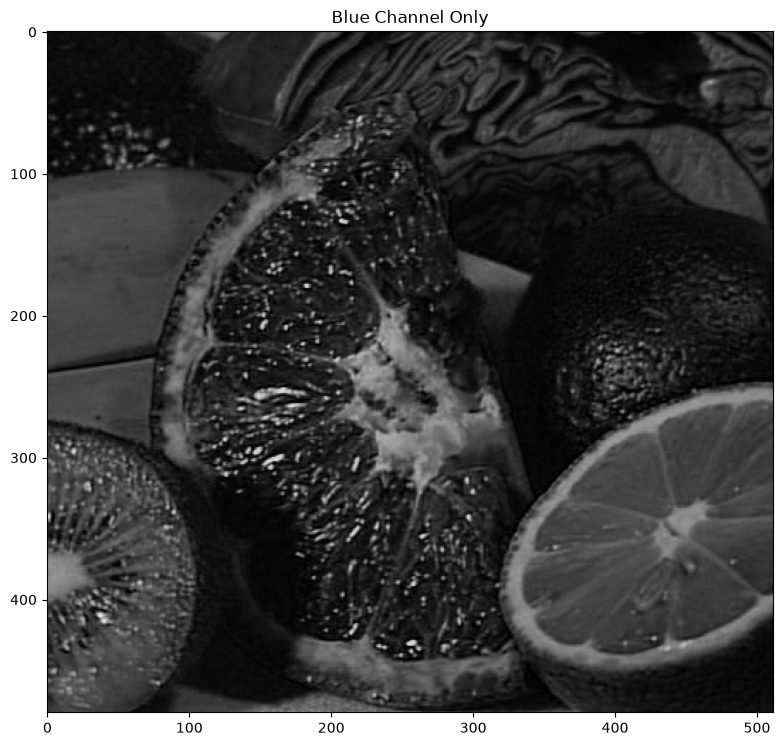

In [3]:
# Each color space on it's on will look like a grayscale as it lacks the other color channels
imshow("Blue Channel Only", B)

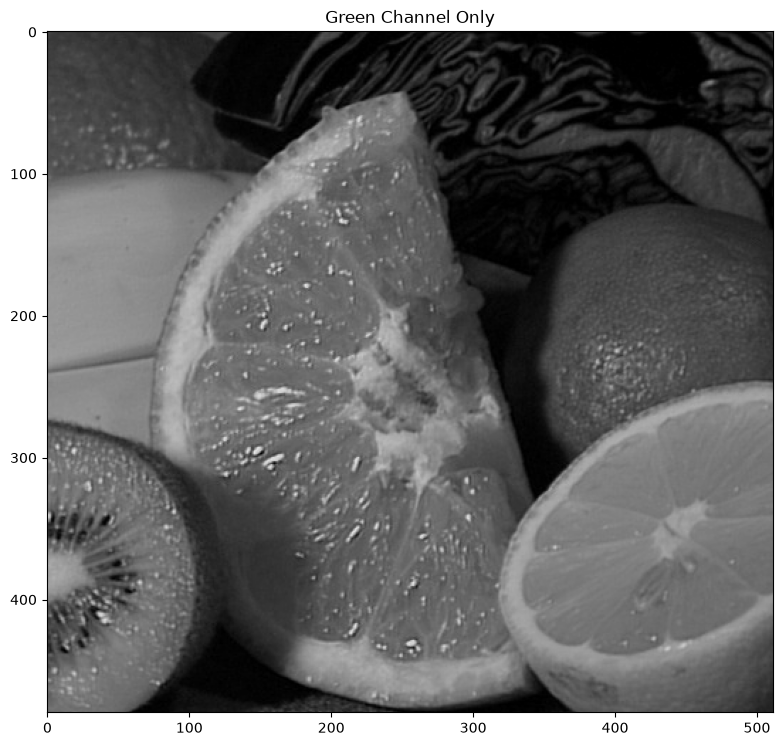

In [4]:
# Each color space on it's on will look like a grayscale as it lacks the other color channels
imshow("Green Channel Only", G)

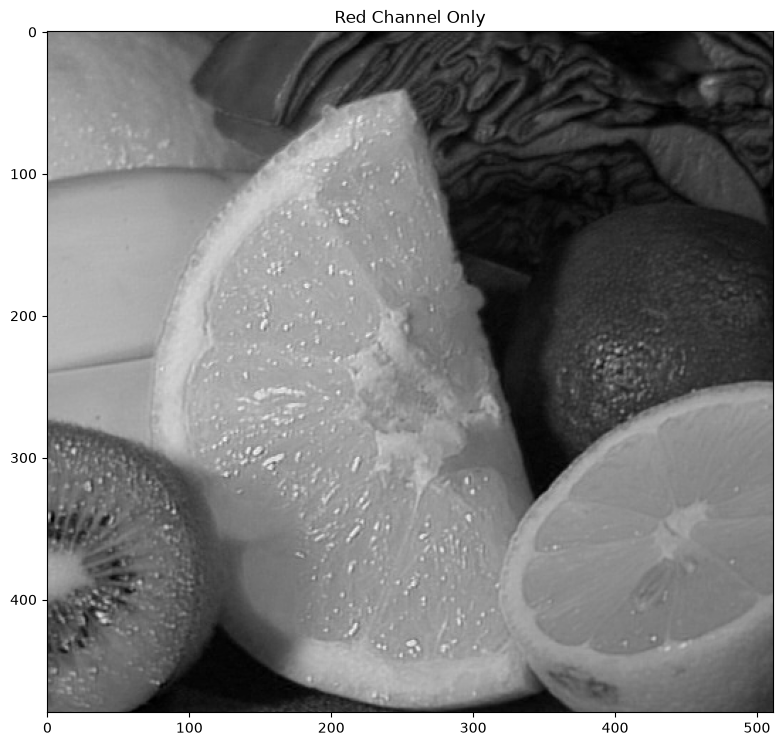

In [5]:
# Each color space on it's on will look like a grayscale as it lacks the other color channels
imshow("Red Channel Only", R)

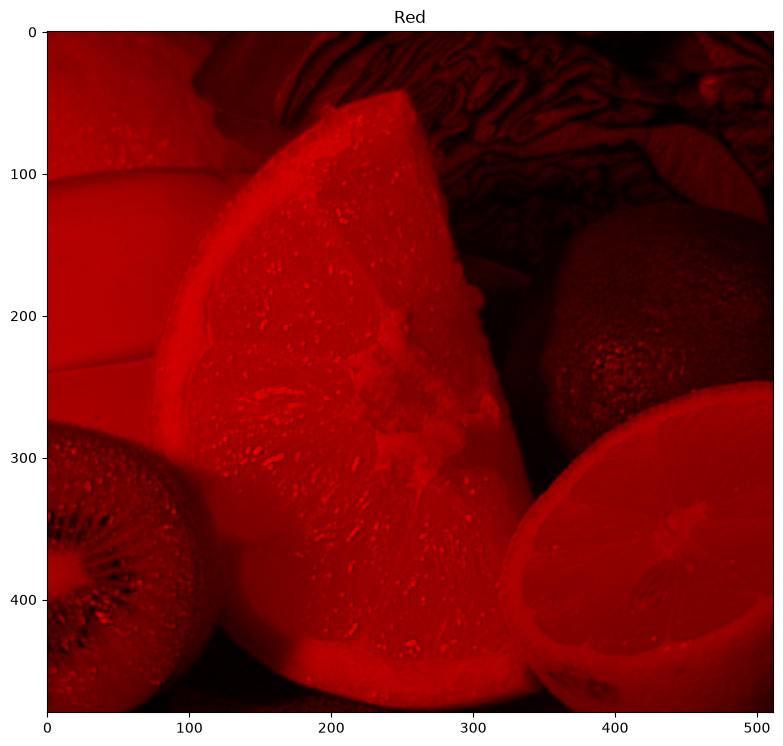

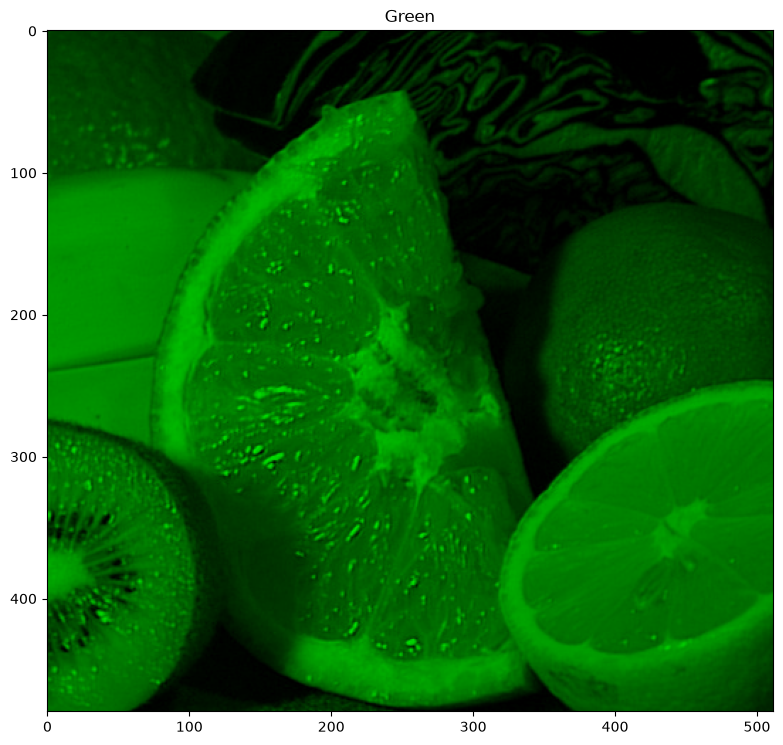

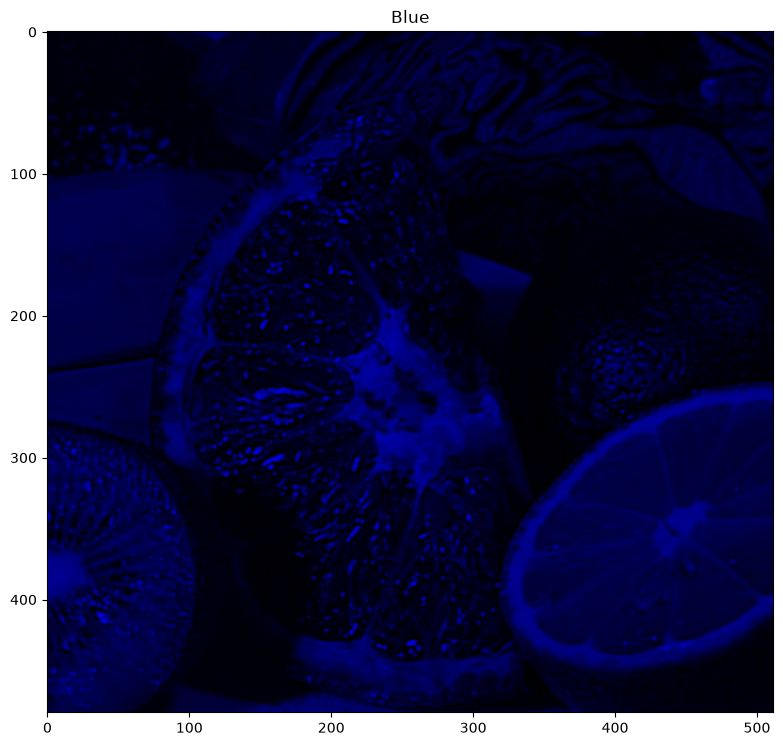

In [6]:
import numpy as np

# Let's create a matrix of zeros 
# with dimensions of the image h x w  
zeros = np.zeros(image.shape[:2], dtype = "uint8")

imshow("Red", cv2.merge([zeros, zeros, R]))
imshow("Green", cv2.merge([zeros, G, zeros]))
imshow("Blue", cv2.merge([B, zeros, zeros]))

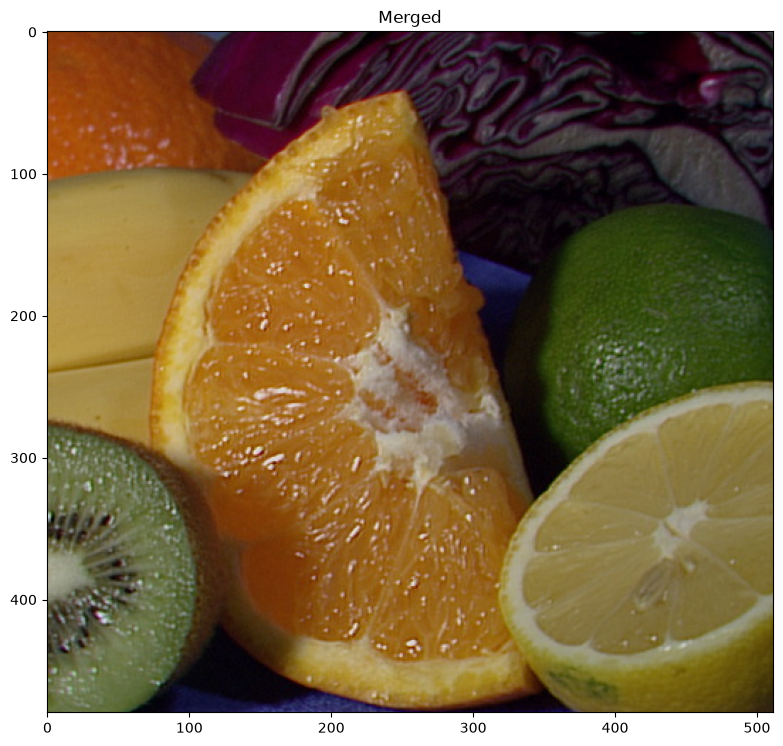

In [7]:
image = cv2.imread('./assets/images/castara.jpeg')

# OpenCV's 'split' function splites the image into each color index
B, G, R = cv2.split(image)

# Let's re-make the original image, 
merged = cv2.merge([B, G, R]) 
imshow("Merged", merged) 

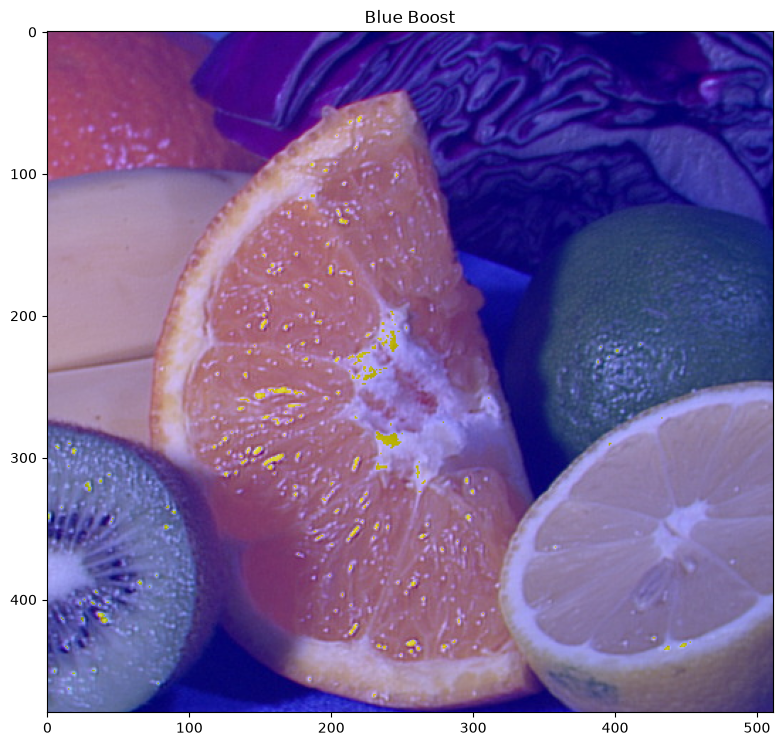

In [8]:
# Let's amplify the blue color
merged = cv2.merge([B+100, G, R])
imshow("Blue Boost", merged)

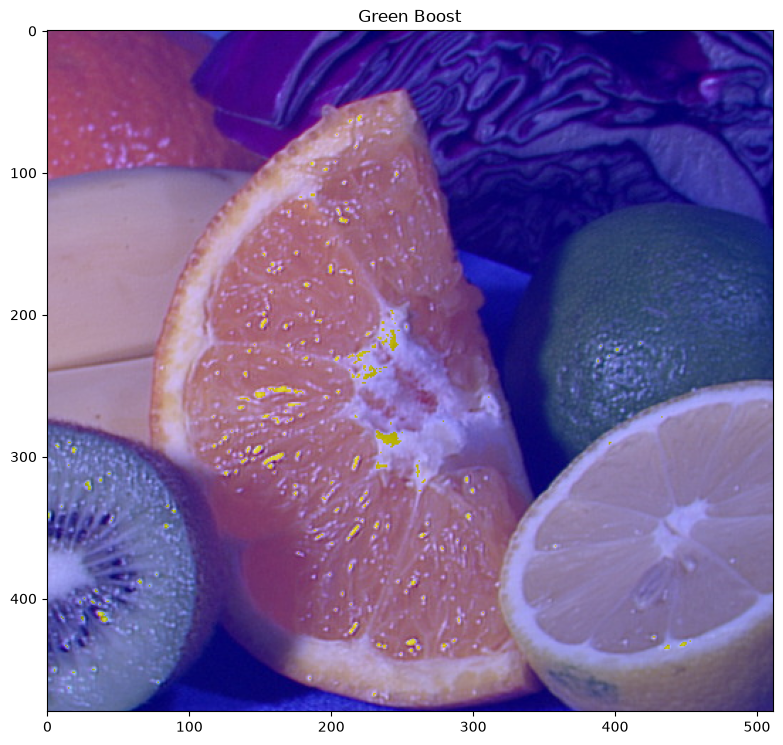

In [9]:
# Let's amplify the Green color
G_merged = cv2.merge([B, G+100, R])
imshow("Green Boost", merged)

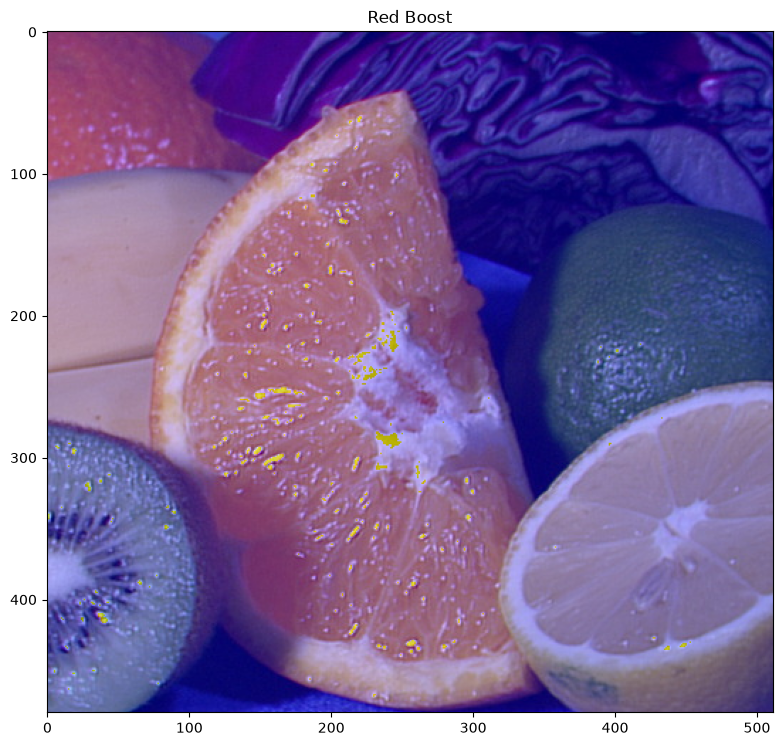

In [10]:
# Let's amplify the Red color
R_merged = cv2.merge([B, G, R+100])
imshow("Red Boost", merged)

## **The HSV Color Space**

![](https://upload.wikimedia.org/wikipedia/commons/f/f2/HSV_color_solid_cone.png)

- Hue: 0 - 179 
- Saturation: 0 - 255
- Value (Intensity): 0 - 255

**Why bother with HSV when RGB already describes every color?** In RGB, a color and its brightness are tangled together across all three channels — dim red and bright red don't share a coordinate, so 'find anything red' means writing a rule that survives R, G, *and* B all moving at once. HSV untangles them: **Hue** is the color itself (position around a color wheel), **Saturation** is how vivid vs. washed-out it is, **Value** is just brightness. Dim red and bright red now share almost the same Hue — only Value differs. That's the whole reason notebook 21's and 26's `cv2.inRange` color filters convert to HSV first and threshold on Hue: it's one number that stays stable when the lighting changes, which no single RGB channel ever does.

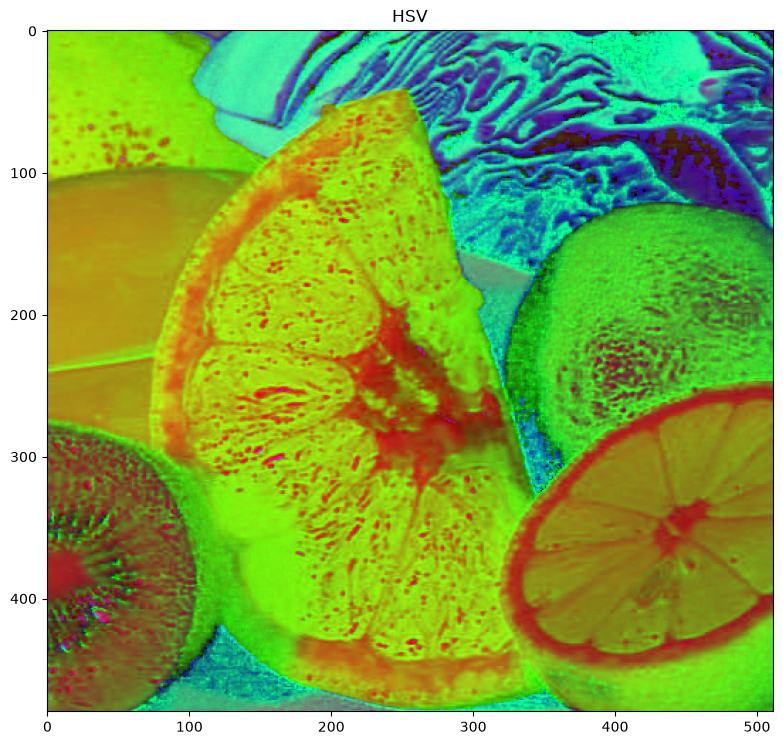

In [11]:
# Reload our image
image = cv2.imread('./assets/images/castara.jpeg')

# Convert to HSV
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
imshow('HSV', hsv_image)

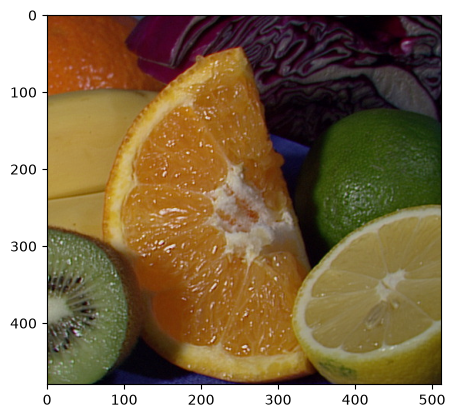

In [12]:
plt.imshow(cv2.cvtColor(hsv_image, cv2.COLOR_HSV2RGB)) # Because we designed plotting function for only RBG images we will have to convert HSV2BGR
plt.show() # Now we will get the right image

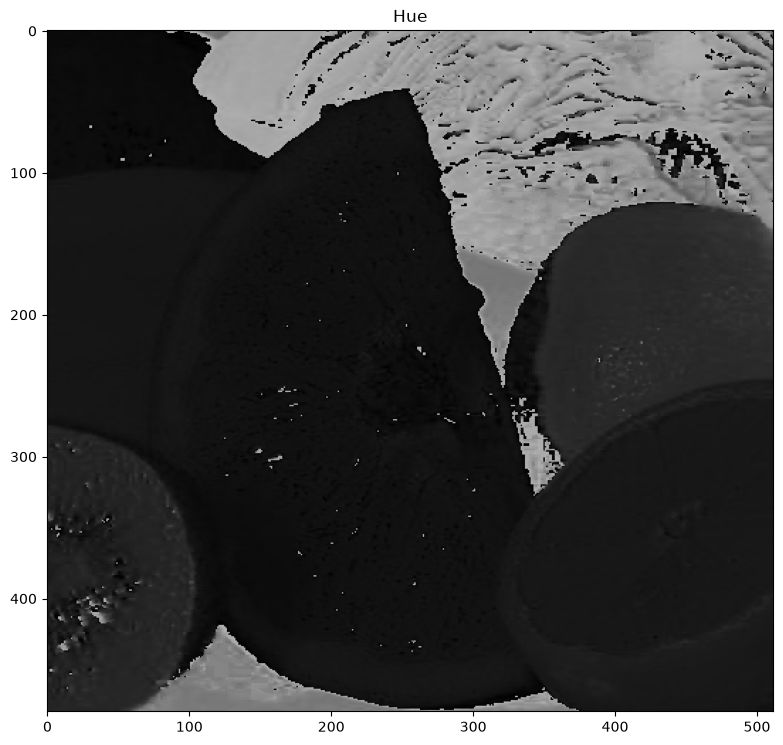

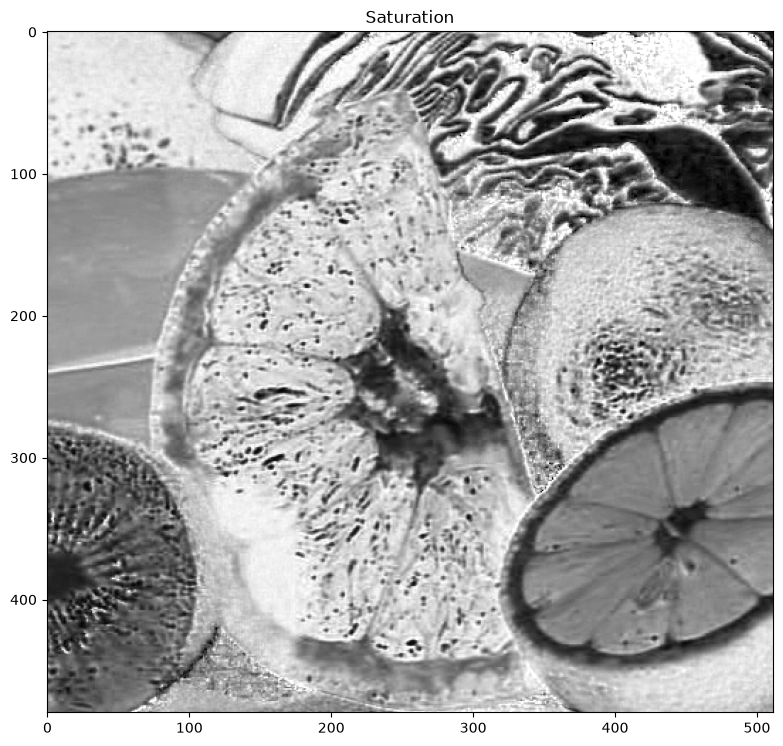

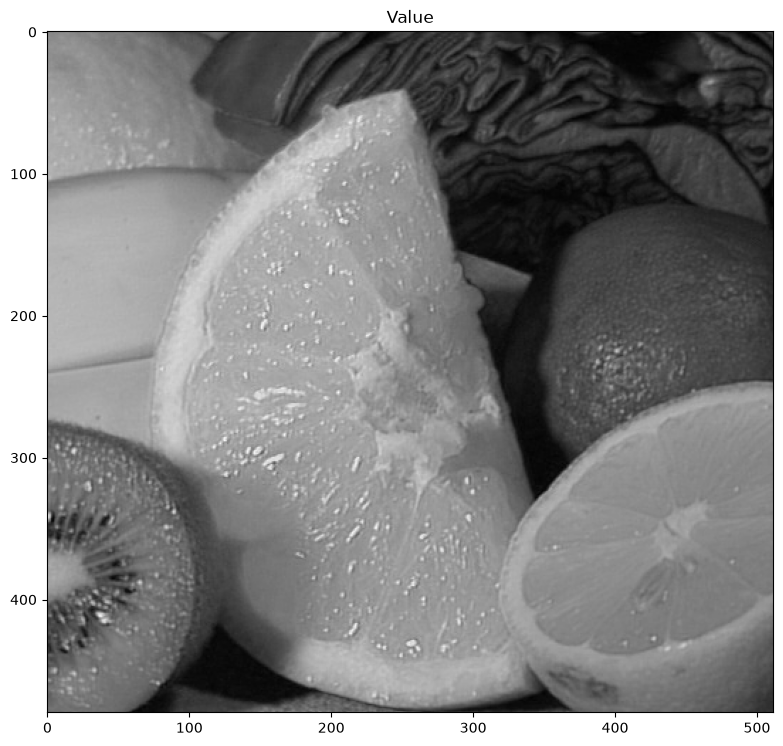

In [13]:
# Switching back to viewing the RGB representation
imshow("Hue", hsv_image[:, :, 0])
imshow("Saturation", hsv_image[:, :, 1])
imshow("Value", hsv_image[:, :, 2])

### A couple of things worth poking at

- LAB and YCrCb are worth knowing too — `cv2.COLOR_BGR2LAB` separates lightness from color, which is why it's often used for illumination-robust processing. Split and view its channels the way this notebook did for HSV.
- Build a simple skin-tone mask: convert to HSV and `cv2.inRange` a hue band around 0–25 — a preview of the color-filtering notebook later in this series.